# 05. Nowcasting French GDP growth with bridge equations and a factor model

**Question.** Can monthly survey and activity data predict the *current* quarter's GDP growth before it is published, and how much does each additional month of data help?

**Design (a pseudo real-time exercise).**
- Target: French GDP growth, quarter on quarter (%), Eurostat.
- Indicators (monthly): economic sentiment indicator (ESI), industrial confidence, consumer confidence, services confidence, retail trade volume growth.
- Three information sets for each quarter: end of month 1, month 2, month 3. Months not yet observed are filled with an AR(1) projection of the indicator (the *ragged edge* problem).
- Models: bridge equations (OLS on the quarterly average of the indicators), ridge on all indicators, and a one-factor (PCA) model. Benchmarks: historical mean of GDP growth and AR(1) on GDP growth.
- Expanding-window estimation, evaluation on 2010Q1 onward, RMSE ratios, Diebold-Mariano tests, with and without the COVID quarters.

**Limits.** Data are the latest vintages, so GDP revisions and survey revisions are ignored (surveys are rarely revised; GDP is). Previous-quarter GDP is assumed available throughout the quarter (true in practice from about day 30). Industrial production and PMIs are not in the free data used here.

In [1]:
import sys, warnings
sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from data_utils import dbnomics
from IPython.display import display
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})

## 1. Data

GDP: 1980Q2 -> 2025Q3 | monthly indicators end: 2025-12
Correlation of quarterly-average indicators with GDP growth, 1999-2019:


,esi,industry,consumers,services,retail_mom
corr with GDP growth,0.58,0.57,0.41,0.5,0.17


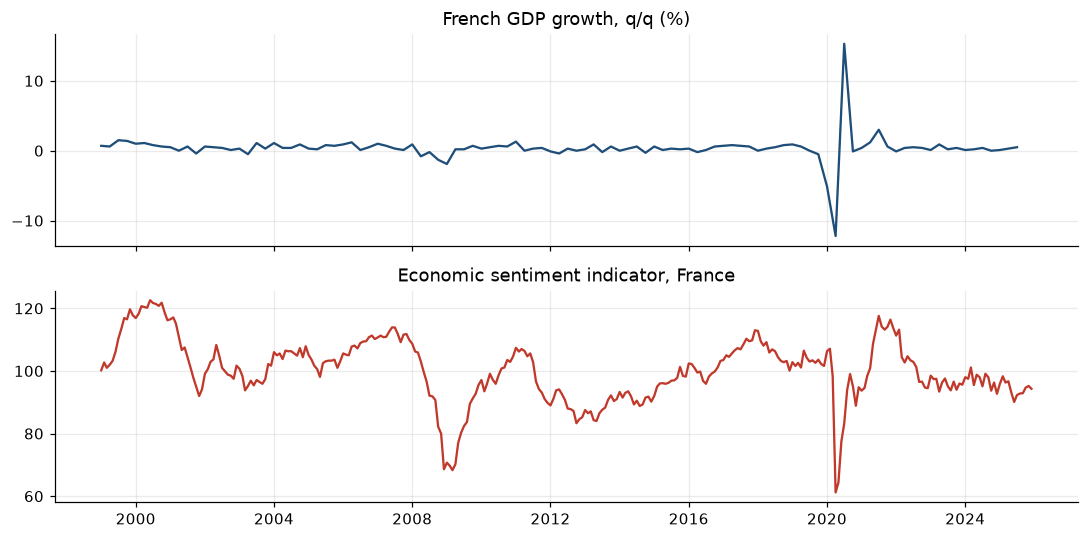

In [2]:
gdp = dbnomics("Eurostat", "namq_10_gdp", "Q.CLV_PCH_PRE.SCA.B1GQ.FR", "gdp")
gdp.index = gdp.index.to_period("Q")
EU = "Eurostat"
mon = {"esi": ("ei_bssi_m_r2", "M.BS-ESI-I.SA.FR"), "industry": ("ei_bssi_m_r2", "M.BS-ICI-BAL.SA.FR"),
       "consumers": ("ei_bssi_m_r2", "M.BS-CSMCI-BAL.SA.FR"), "services": ("ei_bssi_m_r2", "M.BS-SCI-BAL.SA.FR")}
M = pd.DataFrame({k: dbnomics(EU, ds, code, k) for k, (ds, code) in mon.items()})
retail = dbnomics(EU, "sts_trtu_m", "M.VOL_SLS.G47.SCA.I21.FR", "retail")
M["retail_mom"] = 100 * np.log(retail).diff()
M.index = M.index.to_period("M")
M = M.loc["1999-01":].sort_index()
print("GDP:", gdp.index[0], "->", gdp.index[-1], "| monthly indicators end:", M.dropna(how="all").index[-1])
print("Correlation of quarterly-average indicators with GDP growth, 1999-2019:")
Q = M.groupby(M.index.asfreq("Q")).mean()
display(Q.join(gdp).loc["1999":"2019"].corr()["gdp"].drop("gdp").round(2).to_frame("corr with GDP growth").T)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
g = gdp.loc["1999":]; e = M["esi"].dropna()
axes[0].plot(g.index.to_timestamp(), g.values, color="#1f4e79"); axes[0].set_title("French GDP growth, q/q (%)")
axes[1].plot(e.index.to_timestamp(), e.values, color="#c0392b"); axes[1].set_title("Economic sentiment indicator, France")
plt.tight_layout(); plt.savefig("figures/05_data.png"); plt.show()

## 2. Ragged edge and quarterly features
At the end of month *k* of a quarter, months k+1..3 are unknown. Each indicator is projected forward with an AR(1) fitted on data up to that month; the quarterly feature is the average of the three months (observed or projected).

In [3]:
IND = list(M.columns)

def ar1_fill(s, last, n_ahead):
    """Project n_ahead months after `last` using AR(1) fitted on s up to `last` (expanding window)."""
    x = s.loc[:last].dropna()
    y, xl = x.iloc[1:].values, x.iloc[:-1].values
    A = np.column_stack([np.ones(len(xl)), xl]); c, phi = np.linalg.lstsq(A, y, rcond=None)[0]
    phi = min(max(phi, -0.99), 0.99); mu = c / (1 - phi); v = x.iloc[-1]; out = []
    for _ in range(n_ahead):
        v = mu + phi * (v - mu); out.append(v)
    return out

def features(q, k):
    """Quarterly features for quarter q using info through month k (1,2,3) of that quarter."""
    months = [q.asfreq("M", "s") + i for i in range(3)]
    last = months[k - 1]
    f = {}
    for c in IND:
        vals = [M[c].get(m, np.nan) for m in months[:k]]
        if any(np.isnan(vals)): return None
        f[c] = np.mean(vals + ar1_fill(M[c], last, 3 - k))
    return f

def full_features(q):
    return features(q, 3)

## 3. Models and out-of-sample evaluation
At each target quarter *q*, the models are estimated on quarters before *q* with full-quarter features, then applied to the partial-information features of *q*.

In [4]:
QS = [q for q in gdp.index if q >= pd.Period("1999Q2") and full_features(q) is not None]
FULL = pd.DataFrame({q: full_features(q) for q in QS}).T
TEST = [q for q in QS if q >= pd.Period("2010Q1") and q in gdp.index]

def nowcast(q, k):
    train = [t for t in QS if t < q]
    y = gdp.reindex(train).values; Xtr = FULL.loc[train]
    xf = features(q, k)
    if xf is None: return None
    xn = pd.DataFrame([xf])[IND]
    prev = gdp.get(q - 1, np.nan)
    out = {"mean": float(y.mean())}
    # AR(1) on GDP
    ylag = gdp.reindex([t - 1 for t in train]).values; ok = ~np.isnan(ylag)
    ar = sm.OLS(y[ok], sm.add_constant(ylag[ok])).fit(); out["AR1"] = float(ar.params[0] + ar.params[1] * prev)
    # bridge on ESI only (+ lagged GDP)
    Xb = sm.add_constant(pd.DataFrame({"esi": Xtr["esi"].values, "lag": np.where(ok, ylag, np.nanmean(ylag))}))
    mb = sm.OLS(y, Xb).fit(); out["Bridge-ESI"] = float(mb.params @ [1, xn["esi"].iloc[0], prev])
    # ridge on all indicators
    sc = StandardScaler().fit(Xtr); rg = Ridge(alpha=10.0).fit(sc.transform(Xtr), y)
    out["Ridge-all"] = float(rg.predict(sc.transform(xn))[0])
    # one-factor PCA model
    pca = PCA(1).fit(sc.transform(Xtr)); fz = pca.transform(sc.transform(Xtr)).ravel()
    sign = np.sign(np.corrcoef(fz, Xtr["esi"])[0, 1]); mf = sm.OLS(y, sm.add_constant(sign * fz)).fit()
    out["Factor"] = float(mf.params @ [1, sign * pca.transform(sc.transform(xn))[0, 0]])
    out["Pool"] = np.mean([out["Bridge-ESI"], out["Ridge-all"], out["Factor"]])
    return out

rows = []
for q in TEST:
    for k in (1, 2, 3):
        nc = nowcast(q, k)
        if nc is not None:
            rows.append({"quarter": q, "month": k, "actual": float(gdp[q]), **nc})
R = pd.DataFrame(rows)
print(R.groupby("month").size().to_dict(), "nowcasts per information set")
R.to_csv("data/out_05_nowcasts.csv", index=False)

{1: 63, 2: 63, 3: 63} nowcasts per information set


In [5]:
def dm(e0, e1):
    d = e0 ** 2 - e1 ** 2; n = len(d)
    v = d.var(ddof=1) / n
    t = d.mean() / np.sqrt(v) * np.sqrt((n - 1) / n)
    return 1 - stats.t.cdf(t, n - 1)

MODELS = ["mean", "Bridge-ESI", "Ridge-all", "Factor", "Pool"]
def eval_table(mask=None, bench="AR1"):
    out = {}
    for k in (1, 2, 3):
        d = R[R.month == k]
        if mask is not None: d = d[mask(d)]
        e = {m: (d[m] - d.actual).values for m in MODELS + ["AR1"]}
        row = {f"{bench} RMSE": f"{np.sqrt((e[bench] ** 2).mean()):.3f}", "n": len(d)}
        for m in [x for x in MODELS + ["AR1"] if x != bench]:
            p = dm(e[bench], e[m]); st = "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""
            row[m] = f"{np.sqrt((e[m] ** 2).mean()) / np.sqrt((e[bench] ** 2).mean()):.2f}{st}"
        out[f"end of month {k}"] = row
    return pd.DataFrame(out).T

covid = lambda d: ~d.quarter.isin(pd.period_range("2020Q1", "2021Q2", freq="Q"))
print("ALL QUARTERS 2010Q1 onward (ratio to the AR(1) benchmark RMSE; <1 = better)"); t_all = eval_table(); display(t_all)
print("EXCLUDING 2020Q1-2021Q2 (COVID)"); t_ex = eval_table(covid); display(t_ex)
print("EXCLUDING COVID, benchmark = historical mean of GDP growth (the tougher test)"); t_mean = eval_table(covid, bench="mean"); display(t_mean)
t_all.to_csv("data/out_05_table_all.csv"); t_ex.to_csv("data/out_05_table_excovid.csv"); t_mean.to_csv("data/out_05_table_vs_mean.csv")

ALL QUARTERS 2010Q1 onward (ratio to the AR(1) benchmark RMSE; <1 = better)


,AR1 RMSE,n,mean,Bridge-ESI,Ridge-all,Factor,Pool
end of month 1,4.585,63,0.57,1.06,0.54,0.58,0.71
end of month 2,4.585,63,0.57,1.06,0.60,0.57,0.72
end of month 3,4.585,63,0.57,1.06,0.65,0.57,0.74


EXCLUDING 2020Q1-2021Q2 (COVID)


,AR1 RMSE,n,mean,Bridge-ESI,Ridge-all,Factor,Pool
end of month 1,0.539,57,0.93*,0.93,0.88,0.89,0.89
end of month 2,0.539,57,0.93*,0.94,0.89,0.91,0.91
end of month 3,0.539,57,0.93*,0.92,0.90,0.90,0.90


EXCLUDING COVID, benchmark = historical mean of GDP growth (the tougher test)


,mean RMSE,n,Bridge-ESI,Ridge-all,Factor,Pool,AR1
end of month 1,0.502,57,1.00,0.95,0.96,0.96,1.07
end of month 2,0.502,57,1.01,0.96,0.98,0.97,1.07
end of month 3,0.502,57,0.99,0.97,0.97,0.96,1.07


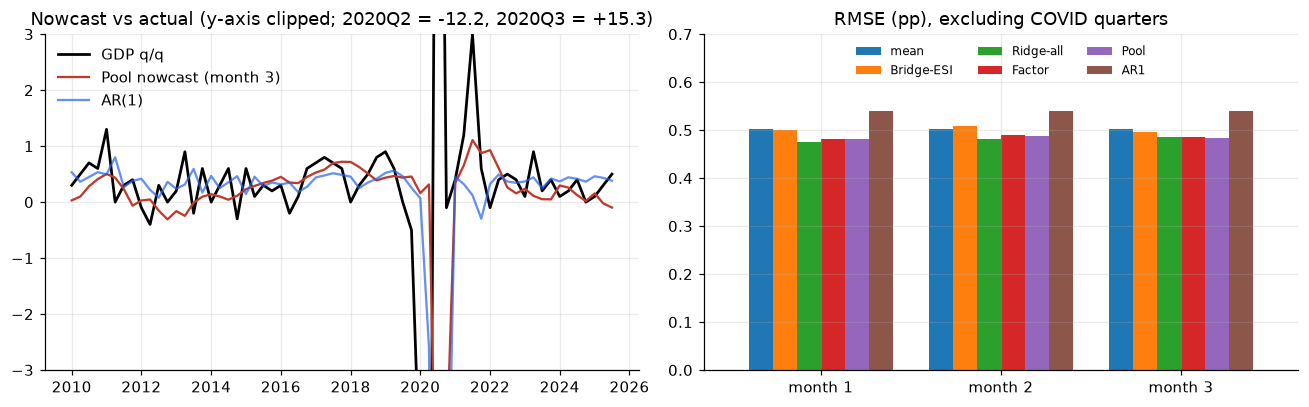

In [6]:
d3 = R[R.month == 3].set_index("quarter"); idx = d3.index.to_timestamp()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(idx, d3.actual, "k", lw=1.8, label="GDP q/q"); axes[0].plot(idx, d3["Pool"], color="#c0392b", label="Pool nowcast (month 3)"); axes[0].plot(idx, d3["AR1"], color="#2563eb", alpha=.7, label="AR(1)")
q2, q3 = d3.actual[pd.Period("2020Q2")], d3.actual[pd.Period("2020Q3")]
axes[0].set_ylim(-3, 3); axes[0].legend(frameon=False); axes[0].set_title(f"Nowcast vs actual (y-axis clipped; 2020Q2 = {q2:+.1f}, 2020Q3 = {q3:+.1f})")
rm = {m: [np.sqrt(((R[R.month == k][m] - R[R.month == k].actual) ** 2)[covid(R[R.month == k])].mean()) for k in (1, 2, 3)] for m in MODELS + ["AR1"]}
pd.DataFrame(rm, index=["month 1", "month 2", "month 3"]).plot.bar(ax=axes[1], rot=0, width=.8); axes[1].set_title("RMSE (pp), excluding COVID quarters")
axes[1].set_ylim(0, 0.7); axes[1].legend(frameon=False, fontsize=8, ncol=3, loc="upper center")
plt.tight_layout(); plt.savefig("figures/05_nowcast.png"); plt.show()

## 4. How to read this
- The question is whether RMSE falls from month 1 to month 3 as more of the quarter's indicators arrive. If it does not, the indicators carry little incremental information.
- Compare the first two tables: COVID quarters dominate squared errors, so results with them are mostly about whether a model reacted to 2020.
- The third table changes the benchmark to the historical mean of GDP growth, which is harder to beat than the AR(1).
- Stars refer to a one-sided Diebold-Mariano test against the benchmark of each table, on about 60 quarters; treat them as indicative.

**Extensions.** Add hard data (industrial production, PMI), use a dynamic factor model with Kalman filter for the ragged edge, real-time GDP vintages, and density nowcasts.